## Analyis of Algorithm

In [1]:
library(terra)
library(sf)
library(dplyr)
library(lwgeom)
library(tidyverse)
library(tictoc)

terra 1.8.93
Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE

Attaching package: ‘dplyr’

The following objects are masked from ‘package:terra’:

    intersect, union

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Linking to liblwgeom 3.0.0beta1 r16016, GEOS 3.12.1, PROJ 9.4.0

Attaching package: ‘lwgeom’

The following objects are masked from ‘package:sf’:

    st_minimum_bounding_circle, st_perimeter

── Attaching core tidyverse packages ────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ ggplot2   4.0.2     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ──────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks terra::extract()
✖ dplyr::filter()  masks stats::fi

In [ ]:
getwd()

[1] "/home/etienne/Desktop/repos/Github_Enterprise/BSc_project/code"

### 1. Load in the data

In [2]:
  t0 <- tic()
r <- terra::rast("../data/thermal_rasters_FINAL/mean_v01emme.tif")

line <- sf::st_read("../data/Centerlines_FINAL/Emme_V01.shp", quiet = TRUE) |> sf::st_zm(TRUE, "ZM")


In [3]:
stopifnot(terra::nlyr(r) == 1) # if not only one layer
names(r) <- "T"
if (terra::is.lonlat(r)) stop("Raster must be in a metric CRS.")


In [4]:
rres   <- terra::res(r)
cell_m <- mean(rres)



In [5]:
  if (!is.na(sf::st_crs(line)) &&
      !identical(terra::crs(r), sf::st_crs(line)$wkt)) {
    line <- sf::st_transform(line, terra::crs(r))

}

# This specific object has only one line, somehtimes there are multible ->  then
# we need to do a join.
line

Simple feature collection with 1 feature and 2 fields
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1205048 xmax: 2620465 ymax: 1226331
Projected CRS: CH1903+ / LV95
  NAME   Length                       geometry
1 Emme 30165.01 LINESTRING (2620465 1205048...

In [6]:
g <- sf::st_union(line)

Dont realy know why this is. It seems to me like this is necessairy because not all data is the same -> Better leave it in

---
### Parameters of the Function

In [7]:
step_m            = 500       # slab length along centerline (m)
buffer_px         = 3         # corridor half-width for reference T (pixels)
delta_C           = 1.0       # temperature anomaly threshold (deg C)
min_patch_area_m2 = 2         # drop patches smaller than this
round_to          = 0.1       # round temperatures to this precision
slab_halfwidth_m  = 60        # lateral half-width of slab polygons (m)
connect_diagonals = TRUE      # 8-connectivity when dissolving patches
union_chunk_size  = 50000L    # max cells per dissolve chunk

In [8]:
  if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
    g <- sf::st_collection_extract(g, "LINESTRING")
  if (inherits(g, "sfc_MULTILINESTRING")) {
    g <- sf::st_line_merge(g)
    if (inherits(g, "sfc_GEOMETRYCOLLECTION"))
      g <- sf::st_collection_extract(g, "LINESTRING")
  }

In [9]:
  if (!inherits(g, "sfc_LINESTRING"))
    stop("Centerline must resolve to a LINESTRING.")
  line <- sf::st_sf(geometry = g)


In [10]:
  rfactor <- if (!is.null(round_to) && round_to > 0) 1 / round_to else NA_real_

rfactor

[1] 10

In [11]:
toc()


0.926 sec elapsed


**Timing**

This first set of steps is very fast. That was to be exected. terra only holds a pointer to the data in memory. Only upon evaluation, data is actually read. sf I am not quite shure. But it is also reasonable, that loading a single line into memory is not computationally expensive. So all the checks of coordinate reference systems etc.

---
### 2. Building slabs

In [12]:
tic("Building slaps")
L <- as.numeric(sf::st_length(line))
S <- step_m

# I am quite shure this has its good reasons why it is how it is.
# if seq yields NULL or something, then you still got a vector with a 0
pos <- sort(unique(c(0, seq(0,1, by = S/ L))))

# number of positions ?
npt <- length(pos)

# this returns a warning, if we e.g. want to do step size 5000m but
# the river segment is not even 5000 m long
if (npt < 2) stop("Too few stations for step = ", S)

In [13]:
# these are simple difference vectors 
from <- pos[1:(npt - 1)]
to   <- pos[2:npt]

k    <- length(from)

# not quite shure, why this is needed. This gets the
# geometry from the sf object which is a dataframe with a column holding the
# geometries
g1   <- sf::st_geometry(line)[1]

g1

Geometry set for 1 feature 
Geometry type: LINESTRING
Dimension:     XY
Bounding box:  xmin: 2607224 ymin: 1205048 xmax: 2620465 ymax: 1226331
Projected CRS: CH1903+ / LV95
LINESTRING (2620465 1205048, 2620390 1205056, 2...

In [14]:
# this returns a list filled with NULL
subs_list <- vector("list", k)

subs_list %>% head()

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

[[5]]
NULL

[[6]]
NULL


In [15]:
# from and to are both arrays
for (j in seq_len(k)) {
  subs_list[[j]] <- lwgeom::st_linesubstring(g1, from[j], to[j])
}

# ?do.call
# ok I see. do.call is like a map. It applies
# the function c() to every element of the subs list
subs <- do.call(c,subs_list)


subs %>% class()

# Ok and additionally it seems, like the objects
# inside subs_list interact with c() in a way that they
# get lumped together to a larger geometry object
# so this is a way of "gluing" the segments together to a single object

# ok now I understand what slabs are.
# these are polygons that got greated from
# a linestring (segments) via e buffer.
# the end of the buffer is flatt, to this
# sort of creates rectanlge
# 
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)
slabs_sf <- sf::st_sf(geometry = slabs)



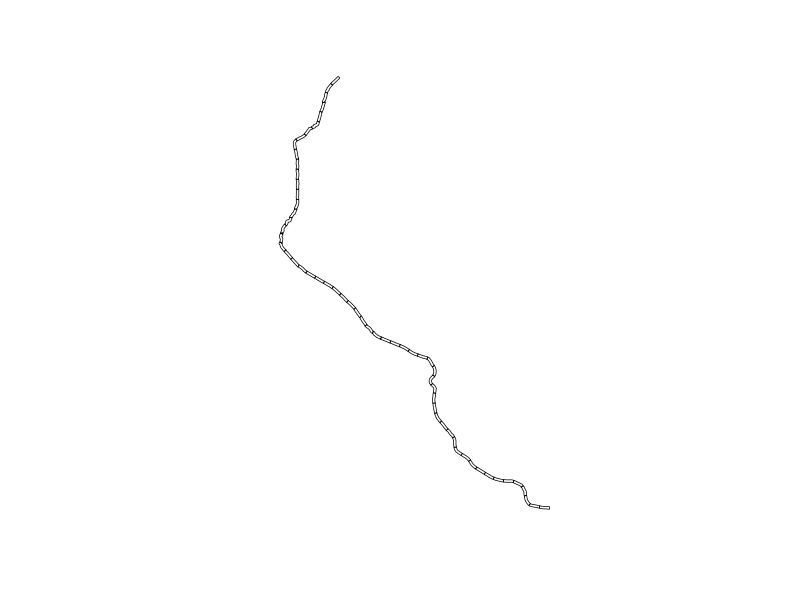

In [16]:
slabs_sf %>% plot()

These are nsome nice slaps ngl

In [17]:
toc()

Building slaps: 0.719 sec elapsed


In [18]:
?st_buffer

**Timing**

This slap building steps also seems to be rather fast. No wonder, as the geodata in play here is very light weight and the rest are just native R functions. (So far this is great but Im rather certain, that the whole number crunching is up ahead)

---
### 3. Extract slab pixels

In [19]:
slabs_terra <- terra::vect(slabs_sf)

In [20]:
# terra::extract(r, slabs_terra, cells = TRUE)

This seems to be very very memory intensive. (It is, since this basically creates a dataframe that holds a row for every pixel.) Idk, this is maybe a super fast way of doing this whole reference temperature calculations if one has enough memory (I don't). But on the HPC i have plenty of memory.

I guess I will still try to find an alternative way of doing this here. Ofc, the computations over the resulting dataframe can be parallelized (because some of these reference temperature calculations are embarissingly parallel + every slab on its own is parallel too). But I can also parallelize this in terra (hopefully). I think I could build the buffer means using

rasterisation of thinner slaps -> zonal operation with the thiner slap raster. And then I could do reclassification of the big slaps using the means of the smaller slaps (median buffers) as burn in. Then all that would be left is some raster algebra.

The neat part is, that this is all powered by GDAL (like almost everything ofc.). So on the hpc i can just try to krank up the number of threads used by gdal and potentially allready get a decent speedup without even changing that much about the code.

In [21]:
buffer_m <- cell_m *  buffer_px

slabs_buffer <- sf::st_buffer(subs,
                          dist        = buffer_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_buffer_sf <- sf::st_sf(geometry = slabs_buffer)


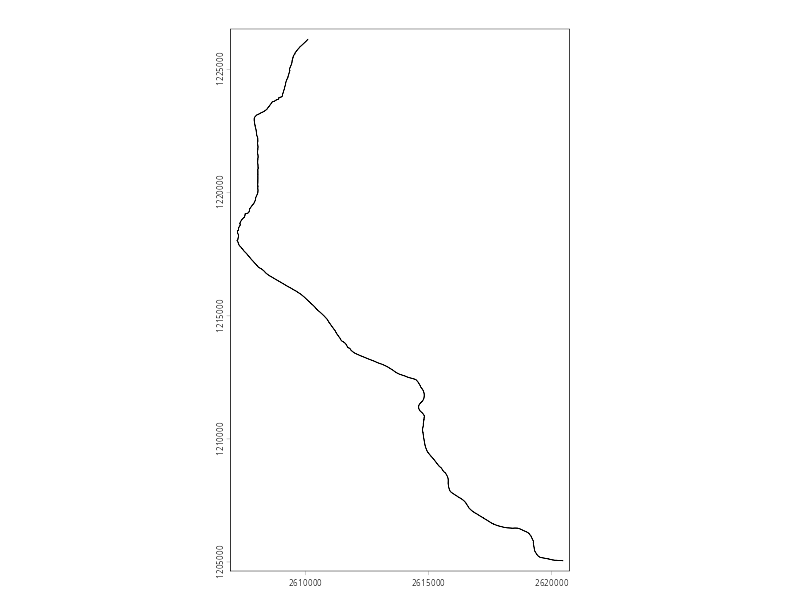

In [22]:
slaps_buffer_vect <- slabs_buffer_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()


slaps_buffer_vect %>% plot()

In [23]:
zone_r <- terra::rasterize(slaps_buffer_vect, r, field = "slap_id")

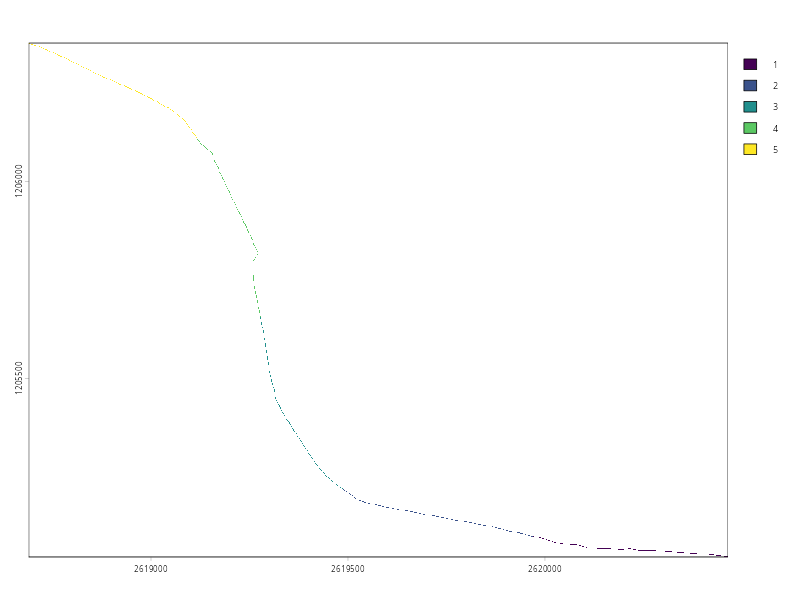

In [24]:
# The full raster is ~64k x ~103k pixels at 0.207m resolution.
# At that scale, 6-pixel-wide buffer slabs appear as sub-pixel dots.
# Zoom into the first few slabs to verify they are real polygons:
ext_zoom <- terra::ext(slaps_buffer_vect[1:5, ])
terra::plot(terra::crop(zone_r, ext_zoom))
#terra::plot(slaps_buffer_vect[1:5, ], add = TRUE, border = "red")

In [25]:
mean_raster <- terra::zonal(r, zone_r,fun = "mean", na.rm = TRUE)

In [26]:
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_raster <- terra::rast()

In [27]:
slabs <- sf::st_buffer(subs,
                          dist        = slab_halfwidth_m,
                          endCapStyle = "FLAT",
                          joinStyle   = "MITRE",
                          mitreLimit  = 2)


slabs_sf <- sf::st_sf(geometry = slabs)


slaps_sf_vect <- slabs_sf %>%
  mutate(slap_id = row_number()) %>%
  terra::vect()


zone_r_big <- terra::rasterize(slaps_sf_vect, r, field = "slap_id")


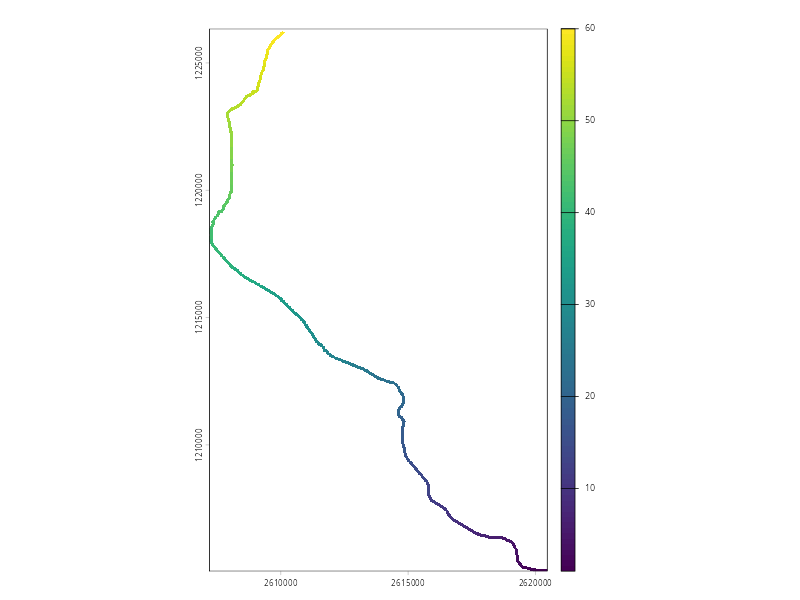

In [28]:
plot(zone_r_big)

In [29]:
Tmean <- terra::classify(zone_r_big,mean_raster)

In [ ]:
flagged_pixels <- r - Tmean



In [39]:
binary <- flagged_pixels <= (-1* delta_C)



In [40]:

binary[binary==0] <- NA

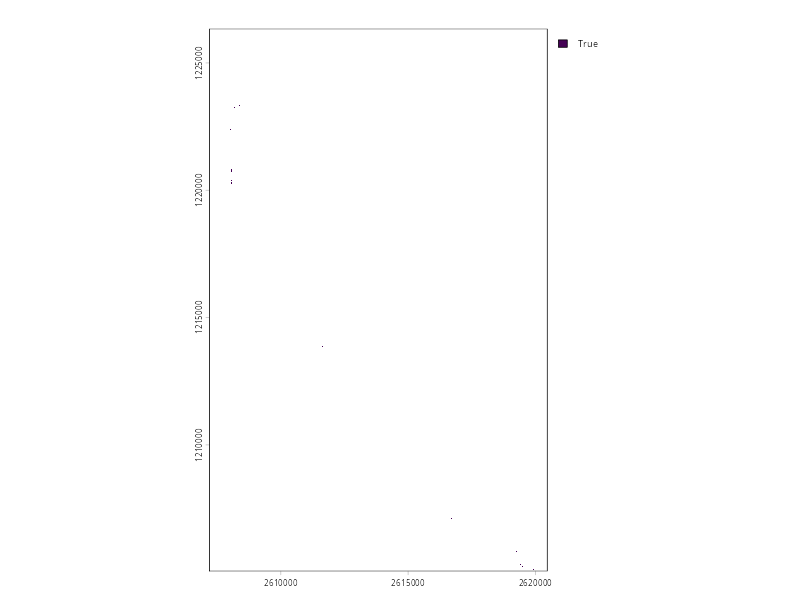

In [41]:
binary %>% plot()

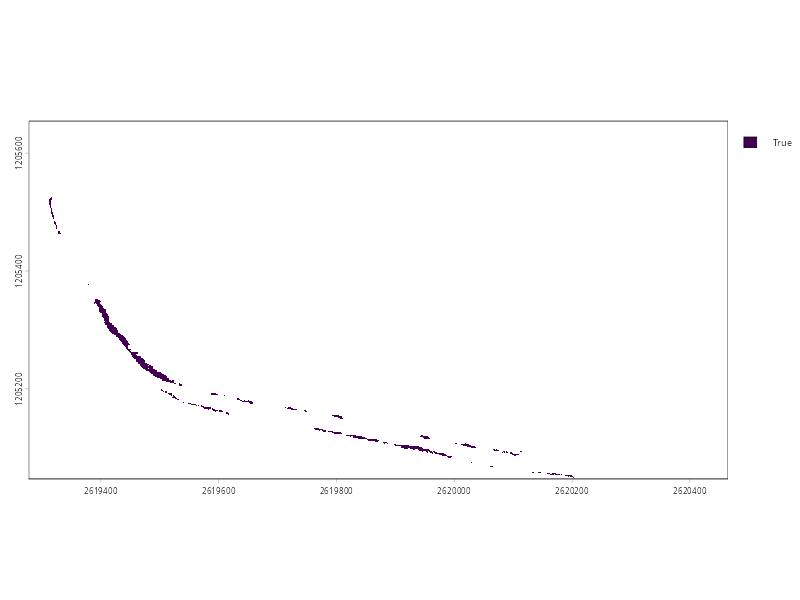

In [42]:
ext_zoom <- terra::ext(slaps_buffer_vect[1:3, ])
terra::plot(terra::crop(binary, ext_zoom))

In [44]:

patches_v <- terra::as.polygons(binary,
                                 dissolve = TRUE,
                                 eight    = FALSE)

A connectivity of eight is no longer needed since this logic is allready a side effect of the morphological closing.

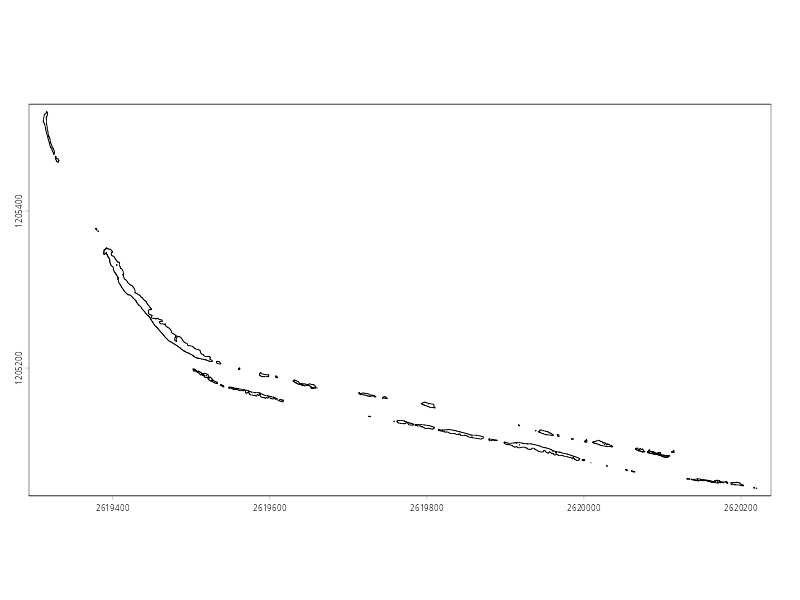

In [47]:
ext_zoom <- terra::ext(slaps_buffer_vect[1:3, ])
terra::plot(terra::crop(patches_v, ext_zoom))

In [49]:
patches_sf <- sf::st_as_sf(patches_v) %>% sf::st_cast("POLYGON") 

Warning message:
In st_cast.sf(., "POLYGON") :
  repeating attributes for all sub-geometries for which they may not be constant


In [53]:
patches_large <- patches_sf %>%
  filter(as.numeric(st_area(.)) >= 2)

In [55]:
patches_large %>%
terra::extract(r, . , fun = function(x) c(
  mean   = mean(x,           na.rm = TRUE),
  min    = min(x,            na.rm = TRUE),
  max    = max(x,            na.rm = TRUE),
  median = stats::median(x,  na.rm = TRUE)
))

        ID        T      T.1      T.2      T.3
  [1,]   1 19.51852 17.41273 19.93048 19.79858
  [2,]   2 18.76966 18.04250 19.80846 18.67249
  [3,]   3 19.83766 19.65713 19.93000 19.86273
  [4,]   4 19.66133 18.88653 19.92964 19.84624
  [5,]   5 17.81316 16.71403 19.89684 17.51840
  [6,]   6 18.56007 16.72549 19.91997 18.77168
  [7,]   7 18.11144 16.45720 19.92277 18.21997
  [8,]   8 19.54951 19.46278 19.59039 19.55314
  [9,]   9 19.36301 19.14637 19.62352 19.35203
 [10,]  10 18.09235 17.36885 19.62320 17.74333
 [11,]  11 20.72566 19.75143 21.71914 20.70200
 [12,]  12 21.62556 21.44038 21.75465 21.63828
 [13,]  13 20.39065 16.74976 21.75711 20.61994
 [14,]  14 21.23122 20.50975 21.73454 21.25813
 [15,]  15 19.90704 16.26002 21.75699 19.94309
 [16,]  16 21.36284 21.20992 21.45107 21.36845
 [17,]  17 18.37932 18.18520 18.50606 18.40324
 [18,]  18 18.27417 18.02564 18.50796 18.26700
 [19,]  19 17.20298 16.35851 18.50868 17.02512
 [20,]  20 16.76642 16.55402 17.01748 16.75624
 [21,]  21 16